# EDA + Baseline Logistic Regression — Bank Marketing

**Цель датасета:** предсказать, подпишется ли клиент банка на срочный депозит (`y = yes/no`).

**Источник:** португальский банк, телефонные маркетинговые кампании 2008–2010 гг.

---
**Наш план:**
1. Загрузим данные
2. Изучим структуру (EDA)
3. Построим графики
4. Обучим первую модель — Logistic Regression
5. Оценим качество

## Cell 1 — Импорты

Собираем все библиотеки в одном месте — это хороший стиль: сразу видно зависимости проекта.

- `pandas` — работа с таблицами (DataFrame)
- `numpy` — математика и массивы
- `matplotlib / seaborn` — графики (seaborn — обёртка над matplotlib с красивыми дефолтами)
- `sklearn` — ML-модели, метрики, предобработка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)

# Чтобы графики отображались прямо в ноутбуке
%matplotlib inline

# Стиль графиков seaborn
sns.set_theme(style='whitegrid', palette='muted')

print('✓ Импорты выполнены')

✓ Импорты выполнены


## Cell 2 — Загрузка данных

**Почему `sep=';'`?**  
CSV расшифровывается как *Comma-Separated Values*, но запятая — лишь конвенция.  
В этом датасете разделитель — точка с запятой `;`. Если не указать `sep`, pandas решит, что весь датасет — одна колонка.

**Относительный путь `data/bank-full.csv`** работает, если ноутбук запущен из папки `bank/`.
Jupyter по умолчанию ставит рабочую директорию туда, где лежит `.ipynb`.

In [25]:
df = pd.read_csv('data/bank-full.csv', sep=';')

print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} колонок')
df.head()

Датасет загружен: 45211 строк, 17 колонок


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Cell 3 — Первичный осмотр

Три ключевых метода для понимания данных:

| Метод | Что показывает |
|---|---|
| `df.info()` | Типы колонок, количество непустых значений, память |
| `df.describe()` | Статистики числовых колонок: mean, std, min, max, квартили |
| `df.isnull().sum()` | Количество пропусков в каждой колонке |

In [3]:
print('=== df.info() ===')
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
print('=== df.describe() — числовые колонки ===')
df.describe().round(2)

=== df.describe() — числовые колонки ===


,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [5]:
# describe() для категориальных колонок
print('=== df.describe(include="object") — категориальные колонки ===')
df.describe(include='object')

=== df.describe(include="object") — категориальные колонки ===


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## Cell 4 — Проверка пропусков

**Почему это важно?**  
Большинство ML-алгоритмов (в т.ч. Logistic Regression) не умеют работать с `NaN`.  
Если не обработать пропуски — получим ошибку или тихо некорректные результаты.

В этом датасете пропусков нет, но так бывает редко — это скорее исключение.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропусков': missing,
    '% от датасета': missing_pct
})

print('=== Пропущенные значения ===')
print(missing_df[missing_df['Пропусков'] > 0] if missing.sum() > 0 else 'Пропусков нет!')

=== Пропущенные значения ===
Пропусков нет!


## Cell 5 — Распределение таргета (целевой переменной)

**Дисбаланс классов** — когда один класс встречается намного реже другого.  
Это критически важно, потому что:

> Модель, которая **всегда предсказывает `no`**, получит accuracy ~88%, но будет абсолютно бесполезна!

Именно поэтому accuracy сама по себе — плохая метрика при дисбалансе.  
Нам нужны **precision, recall, F1 и ROC-AUC**.

=== Распределение таргета y ===
     Количество     %
y                    
no        39922  88.3
yes        5289  11.7


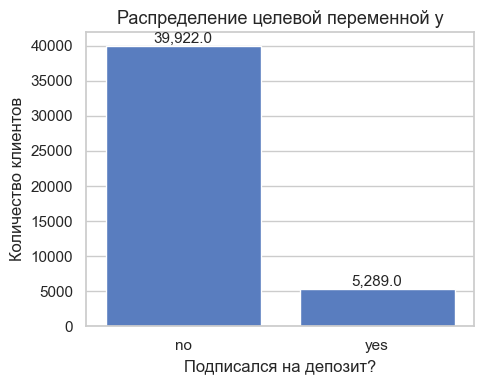

In [7]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print('=== Распределение таргета y ===')
print(pd.DataFrame({'Количество': target_counts, '%': target_pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='y', order=['no', 'yes'], ax=ax)
ax.set_title('Распределение целевой переменной y', fontsize=13)
ax.set_xlabel('Подписался на депозит?')
ax.set_ylabel('Количество клиентов')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 6 — EDA: Графики

Цель EDA-графиков:
- Понять **распределение** числовых признаков (нормальное? Скошенное? Выбросы?)
- Увидеть **связь** признаков с таргетом
- Найти **закономерности** для гипотез

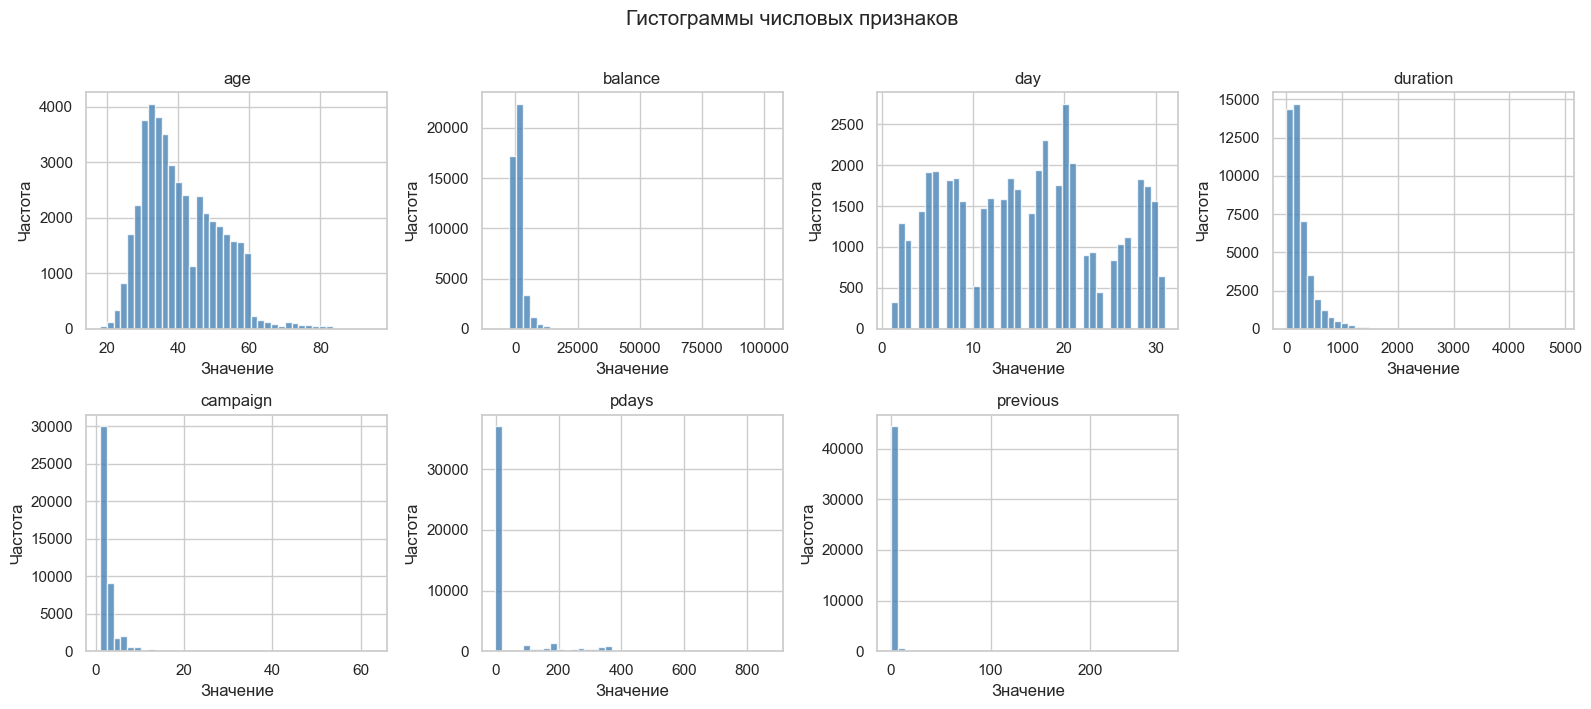


Что видим:
- age: примерно нормальное, большинство 25-60 лет
- balance: сильно скошен вправо (есть богатые клиенты)
- duration: длина звонка — ключевой признак (длинный звонок → скорее "yes")
- campaign: большинство contacted 1-3 раза



In [8]:
# График 1: Гистограммы числовых признаков
# df.hist() строит гистограмму для каждой числовой колонки автоматически

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, edgecolor='white', color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

axes[-1].axis('off')  # последняя ячейка пустая
fig.suptitle('Гистограммы числовых признаков', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('''
Что видим:
- age: примерно нормальное, большинство 25-60 лет
- balance: сильно скошен вправо (есть богатые клиенты)
- duration: длина звонка — ключевой признак (длинный звонок → скорее "yes")
- campaign: большинство contacted 1-3 раза
''')

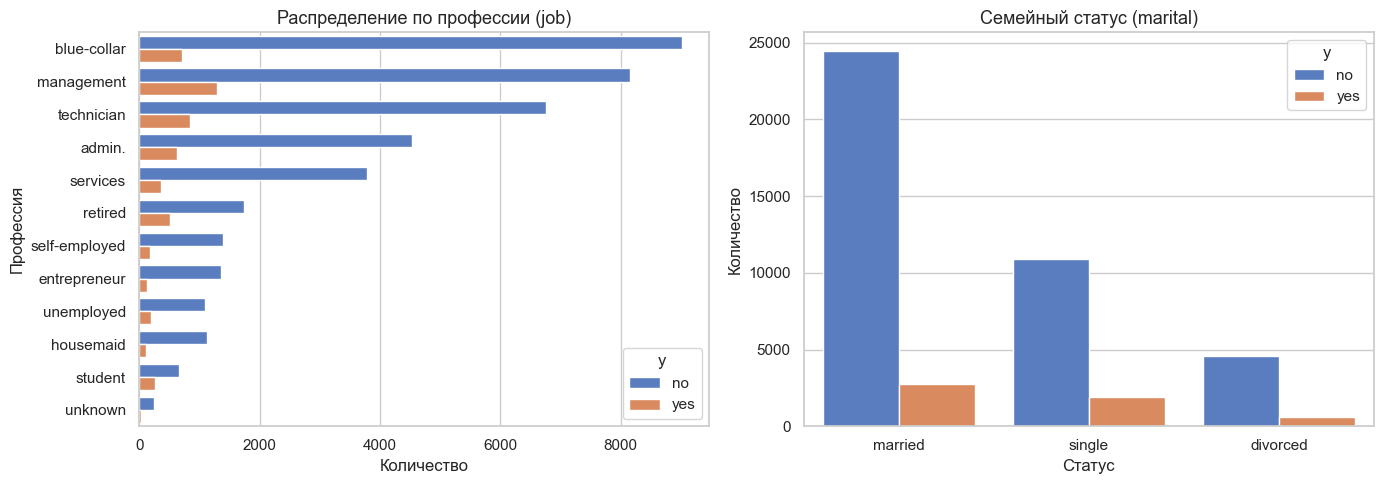

In [9]:
# График 2: Countplot категориальных признаков

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# job
job_order = df['job'].value_counts().index
sns.countplot(data=df, y='job', order=job_order, hue='y', ax=axes[0])
axes[0].set_title('Распределение по профессии (job)', fontsize=13)
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Профессия')

# marital
sns.countplot(data=df, x='marital', hue='y', ax=axes[1])
axes[1].set_title('Семейный статус (marital)', fontsize=13)
axes[1].set_xlabel('Статус')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

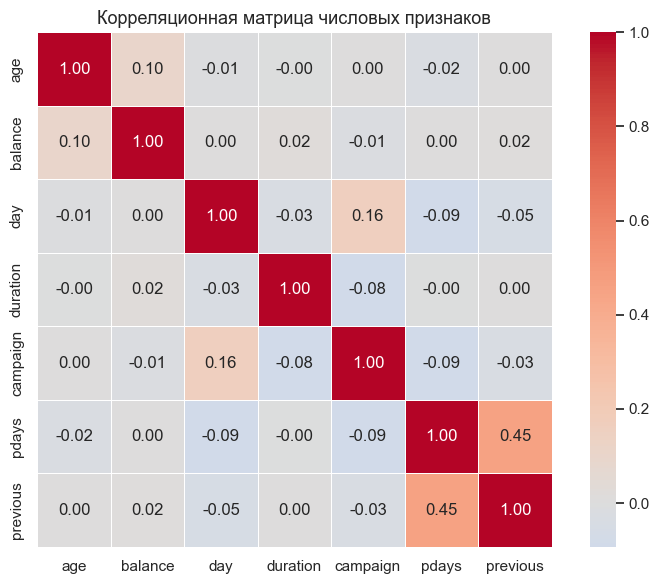

Высокая корреляция между pdays и previous — оба про предыдущие контакты.


In [10]:
# График 3: Корреляционная матрица числовых признаков
# Корреляция Пирсона: от -1 (обратная) до +1 (прямая). 0 = нет линейной связи.

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Корреляционная матрица числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()

print('Высокая корреляция между pdays и previous — оба про предыдущие контакты.')

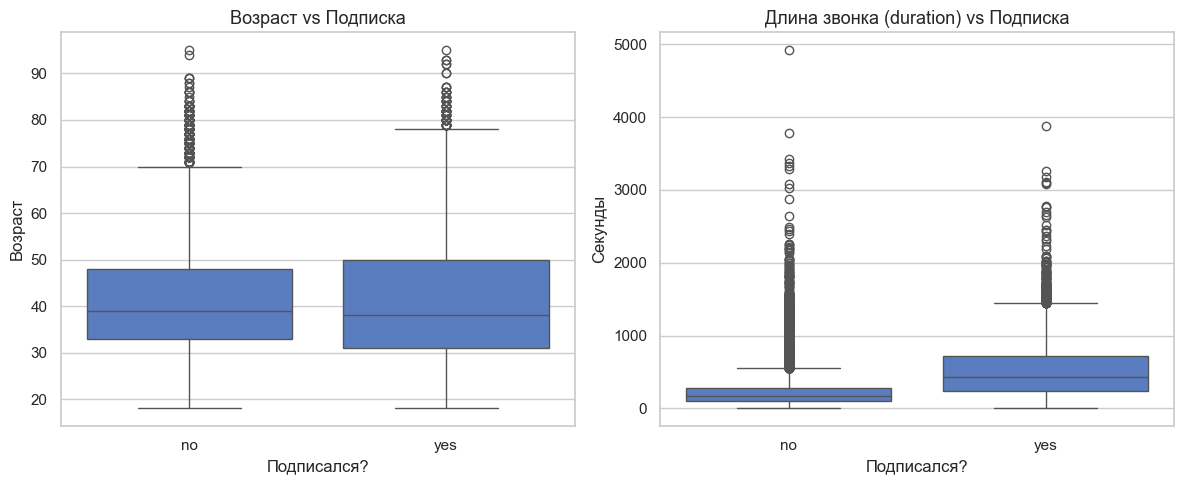

duration у "yes"-клиентов заметно выше — сильный сигнал для модели!


In [11]:
# График 4 (бонус): Boxplot — возраст vs таргет
# Boxplot показывает медиану, квартили и выбросы. Удобен для сравнения двух групп.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='y', y='age', order=['no', 'yes'], ax=axes[0])
axes[0].set_title('Возраст vs Подписка', fontsize=13)
axes[0].set_xlabel('Подписался?')
axes[0].set_ylabel('Возраст')

sns.boxplot(data=df, x='y', y='duration', order=['no', 'yes'], ax=axes[1])
axes[1].set_title('Длина звонка (duration) vs Подписка', fontsize=13)
axes[1].set_xlabel('Подписался?')
axes[1].set_ylabel('Секунды')

plt.tight_layout()
plt.show()

print('duration у "yes"-клиентов заметно выше — сильный сигнал для модели!')

## Cell 7 — Подготовка данных для LogReg

**Почему только числовые признаки?**  
Logistic Regression — линейная модель. Она работает с числами.  
Категориальные признаки (`job`, `marital` и т.д.) нужно сначала закодировать (One-Hot Encoding).  
В baseline мы это пропускаем — сделаем позже.

**Почему StandardScaler?**  
LogReg использует градиентный спуск. Если признаки в разных масштабах  
(например `age` в диапазоне 18–95, а `balance` в –6000..100000),  
обучение будет нестабильным и медленным. Scaler приводит всё к mean=0, std=1.

---

### 🎯 Твоя очередь написать код!

Я подготовил X и y. Твоя задача — реализовать функцию `split_and_scale(X, y)`.  

**Что нужно сделать внутри функции (~8 строк):**
1. Разбить данные на `X_train, X_test, y_train, y_test` через `train_test_split`
2. Применить `StandardScaler`: обучить на train, трансформировать train и test
3. Вернуть `X_train_sc, X_test_sc, y_train, y_test`

**Важные параметры для `train_test_split`:**
- `test_size=0.2` — 20% на тест
- `random_state=42` — для воспроизводимости
- `stratify=y` — ключевой параметр! Без него при дисбалансе тестовая выборка может содержать непропорционально мало примеров класса `yes`

**Подсказка по StandardScaler:**
```python
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform на train
X_test_sc  = scaler.transform(X_test)        # только transform на test (!!)
```
> Почему `.transform()` на тесте, а не `.fit_transform()`? Потому что тестовые данные должны масштабироваться по статистике **обучающей** выборки. Иначе произойдёт `data leakage` — утечка информации из теста в обучение.

In [12]:
# Подготовим X и y — это готово, твоё задание ниже

NUMERIC_FEATURES = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

X = df[NUMERIC_FEATURES].copy()
# Кодируем таргет: 'yes' -> 1, 'no' -> 0
y = (df['y'] == 'yes').astype(int)

print(f'X shape: {X.shape}')
print(f'y distribution: {y.value_counts().to_dict()}')

X shape: (45211, 7)
y distribution: {0: 39922, 1: 5289}


In [27]:
# TODO: реализуй функцию split_and_scale

def split_and_scale(X, y):
    """
    Разбивает данные на train/test и масштабирует признаки.
    
    Параметры:
        X : DataFrame с числовыми признаками
        y : Series с бинарным таргетом
    
    Возвращает:
        X_train_sc, X_test_sc, y_train, y_test
    """
    # --- Напиши свой код здесь (~8 строк) ---
    
    # Разбиваем данные на train и test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Масштабируем признаки
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    return X_train_sc, X_test_sc, y_train, y_test


# Вызов функции
X_train_sc, X_test_sc, y_train, y_test = split_and_scale(X, y)

print(f'Train size: {X_train_sc.shape[0]:,} | Test size: {X_test_sc.shape[0]:,}')
print(f'Train target balance: {y_train.mean():.3f} | Test target balance: {y_test.mean():.3f}')

Train size: 36,168 | Test size: 9,043
Train target balance: 0.117 | Test target balance: 0.117


## Cell 8 — Обучение Logistic Regression

**Что делает LogReg?**  
Находит линейную границу в пространстве признаков, разделяющую классы.  
Возвращает вероятность принадлежности к классу 1 через функцию **sigmoid**.

**Параметры:**
- `max_iter=1000` — максимум итераций оптимизатора (по умолчанию 100, часто не хватает)
- `random_state=42` — для воспроизводимости (используется в некоторых солверах)

In [28]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

print('✓ Модель обучена')
print(f'Количество итераций оптимизатора: {model.n_iter_[0]}')

✓ Модель обучена
Количество итераций оптимизатора: 9


## Cell 9 — Метрики качества

При **дисбалансе классов** нам важны все 5 метрик:

| Метрика | Формула | Что измеряет |
|---|---|---|
| **Accuracy** | (TP+TN)/(все) | Доля верных предсказаний |
| **Precision** | TP/(TP+FP) | Из всех predicted=yes, сколько реально yes? |
| **Recall** | TP/(TP+FN) | Из всех реальных yes, сколько нашла модель? |
| **F1** | 2·P·R/(P+R) | Гармоническое среднее precision и recall |
| **ROC-AUC** | площадь под ROC-кривой | Способность модели ранжировать классы |

> **Recall** особенно важен в банкинге: пропустить клиента, готового открыть депозит (`FN`) — это упущенная выручка.

In [29]:
y_pred = model.predict(X_test_sc)
y_pred_proba = model.predict_proba(X_test_sc)[:, 1]  # вероятность класса 1

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('       МЕТРИКИ BASELINE LOGISTIC REGRESSION')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)

       МЕТРИКИ BASELINE LOGISTIC REGRESSION
  Accuracy  : 0.8875
  Precision : 0.5686
  Recall    : 0.1607
  F1-score  : 0.2506
  ROC-AUC   : 0.8305


In [30]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['no (0)', 'yes (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

      no (0)       0.90      0.98      0.94      7985
     yes (1)       0.57      0.16      0.25      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.57      0.59      9043
weighted avg       0.86      0.89      0.86      9043



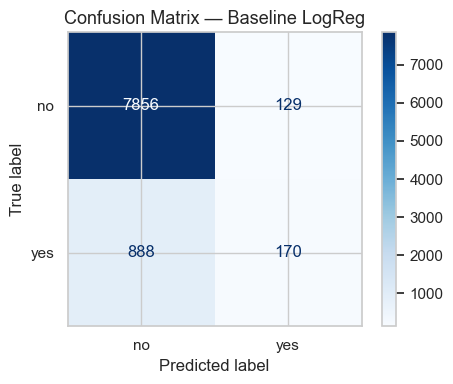

In [31]:
# Confusion Matrix — матрица ошибок
# Строки = реальный класс, Столбцы = предсказанный класс
# TN | FP
# FN | TP

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Baseline LogReg', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 10 — Выводы

### EDA выводы

1. **Дисбаланс классов**: ~88% `no` vs ~12% `yes` — модель может достичь 88% accuracy, просто говоря `no` всегда. Accuracy — не главная метрика здесь.

2. **Признак `duration`** (длина звонка) имеет явную связь с таргетом: клиенты, которые подписались, говорили значительно дольше. Это мощный признак, но есть нюанс: длина звонка известна только *после* его завершения — в реальной задаче его нельзя использовать для предсказания заранее.

3. **Числовые признаки** имеют разные масштабы и распределения: `balance` сильно скошен, `pdays` имеет много значений `-1` (не контактировали). Это потребует дополнительной обработки.


### Что улучшить в следующих итерациях

- [ ] Добавить One-Hot Encoding категориальных признаков
- [ ] Обработать выбросы в `balance` и `duration`
- [ ] Попробовать `class_weight='balanced'` в LogReg для борьбы с дисбалансом
- [ ] Сравнить с Random Forest и Gradient Boosting

---
## Раздел 2 — Полная предобработка данных

До этого момента мы работали только с **7 числовыми** признаками, игнорируя 9 категориальных.  
Теперь используем все 16 — это может существенно улучшить качество модели.

**Что нужно сделать:**
1. Определить тип каждого признака: числовой, бинарный, номинальный или порядковый
2. Закодировать категориальные признаки в числа (разными способами для разных типов)
3. Разбить на train/test с учётом дисбаланса классов (`stratify`)
4. Масштабировать числовые признаки — но только для алгоритмов, которым это нужно

### Какие алгоритмы требуют какой подготовки?

| Алгоритм | Масштабирование | Нужен ли OHE | Почему |
|----------|----------------|--------------|--------|
| Logistic Regression | **Да** | Да | Градиентный спуск, чувствителен к масштабу |
| SVM | **Да** | Да | Расстояния между точками |
| KNN | **Да** | Да | Метрика расстояния |
| Decision Tree | Нет | Да | Ищет пороги, масштаб не важен |
| Random Forest | Нет | Да | Ансамбль деревьев |
| XGBoost / LightGBM | Нет | Часто нет | Умеют обрабатывать категории сами |
| CatBoost | Нет | **Нет** | Специально разработан для категорий |

> **Вывод**: универсальной предобработки нет. Под каждый алгоритм — свои требования.

In [1]:
# Классифицируем все 16 признаков по типу

NUMERIC_COLS = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
BINARY_COLS  = ['default', 'housing', 'loan']           # yes/no → 0/1
NOMINAL_COLS = ['job', 'marital', 'contact', 'month', 'poutcome']  # OHE
ORDINAL_COLS = ['education']                            # порядковый: есть иерархия
# 'y' — таргет (уже закодирован выше как 0/1)

print('Числовые признаки:',   NUMERIC_COLS)
print('Бинарные признаки:',   BINARY_COLS)
print('Номинальные признаки:', NOMINAL_COLS)
print('Порядковые признаки:',  ORDINAL_COLS)

total = len(NUMERIC_COLS) + len(BINARY_COLS) + len(NOMINAL_COLS) + len(ORDINAL_COLS)
print(f'\nВсего признаков перед кодированием: {total} (не считая таргет)')
print('После OHE их будет больше — каждая категория разворачивается в несколько колонок')

Числовые признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Бинарные признаки: ['default', 'housing', 'loan']
Номинальные признаки: ['job', 'marital', 'contact', 'month', 'poutcome']
Порядковые признаки: ['education']

Всего признаков перед кодированием: 16 (не считая таргет)
После OHE их будет больше — каждая категория разворачивается в несколько колонок


## Шаг 2 — Кодирование категориальных признаков

Алгоритмы машинного обучения работают с числами. Категориальные признаки (`job='blue-collar'`) нужно преобразовать.

### Три вида категорий — три метода кодирования

| Тип | Признаки в датасете | Метод | Обоснование |
|-----|---------------------|-------|-------------|
| **Бинарные** (два значения) | `default`, `housing`, `loan` | 0/1 | Ровно два значения → нет смысла в OHE |
| **Номинальные** (без порядка) | `job`, `marital`, `contact`, `month`, `poutcome` | One-Hot Encoding | Нет иерархии — нельзя присвоить число |
| **Порядковые** (с иерархией) | `education` | Ordinal Encoding | Есть порядок: primary < secondary < tertiary |

### Почему нельзя просто присвоить числа номинальным признакам?

Если закодировать `job` как `admin=0, blue-collar=1, entrepreneur=2...`,  
то линейная модель решит: `entrepreneur > blue-collar > admin` (потому что 2 > 1 > 0).  
Это **ложная зависимость** — на самом деле профессии не упорядочены.

**One-Hot Encoding (OHE)**: каждое значение → отдельная бинарная колонка.  
`job_blue-collar=1, job_admin=0, job_entrepreneur=0` — нет ложного порядка.

In [2]:
# Бинарное кодирование: yes/no → 1/0

# Для признаков с ровно двумя значениями OHE избыточен:
# если default=1, то default=0 не нужен — и так понятно

df_binary = pd.DataFrame()
for col in BINARY_COLS:
    df_binary[col] = (df[col] == 'yes').astype(int)

print('Бинарные признаки после кодирования:')
print(df_binary.head(5))
print(f'\nПроверка: default до = {df["default"].value_counts().to_dict()}')
print(f'          default после = {df_binary["default"].value_counts().to_dict()}')

NameError: name 'pd' is not defined

## Шаг 2б — Порядковое кодирование: `education`

### Когда признак **порядковый**, а не просто категориальный?

`job`, `marital`, `contact` — **номинальные**: нет смысла сравнивать "technician > blue-collar".  
`education` — **порядковый**: есть естественная иерархия: primary < secondary < tertiary.

При OHE мы теряем эту иерархию. Модель получит 3 независимых бинарных признака без информации о порядке.  
При ordinal encoding сохраняем: `primary=1, secondary=2, tertiary=3` → модель "видит" градацию.

### Дизайн-решение: что делать с `unknown`?

В датасете ~4% строк имеют `education='unknown'` — это пропуск, а не уровень образования.

**Варианты обработки:**
1. `unknown = 0` — трактуем как "ниже primary" (простой, но искусственный)
2. `unknown = NaN` → imputation (медианой или модой) — честнее, сложнее
3. Добавить `education_is_unknown` (бинарный признак) + кодировать как median

**Мы используем вариант 1** как baseline — простой и достаточный для первых экспериментов.

### 🎯 Твоё задание

В коде ниже — словарь `EDUCATION_ORDER`. Посмотри на него внимательно:
- Попробуй изменить значение для `unknown` и запусти снова — изменится ли что-то?
- Подумай: а стоит ли вообще кодировать education как порядковый? Или лучше OHE?

In [ ]:
# 🎯 Твоё задание: порядковое кодирование education
#
# Категории: 'unknown', 'primary', 'secondary', 'tertiary'
# Задача: назначить каждой категории число, отражающее уровень образования.
#
# Вопрос для размышления:
#   - Правильно ли считать education настоящим ПОРЯДКОВЫМ признаком?
#   - Что делать с 'unknown' — это "ниже primary" или "нет данных"?
#   - Стоит ли добавить отдельный признак 'education_is_unknown' (0/1)?
#
# Ниже — один из вариантов. Можешь изменить порядок или добавить логику.

EDUCATION_ORDER = {
    'unknown'  : 0,   # нет данных → минимальное значение (компромисс)
    'primary'  : 1,   # начальное образование
    'secondary': 2,   # среднее образование
    'tertiary' : 3    # высшее образование
}

df_education_enc = df[['education']].copy()
df_education_enc['education'] = df_education_enc['education'].map(EDUCATION_ORDER)

print('Оригинальные значения → закодированные:')
mapping_check = pd.DataFrame({
    'Оригинал': df['education'].value_counts().index,
    'Код': [EDUCATION_ORDER[v] for v in df['education'].value_counts().index],
    'Количество': df['education'].value_counts().values
})
print(mapping_check.to_string(index=False))
print(f'\nПропуски после кодирования: {df_education_enc["education"].isnull().sum()}')

In [ ]:
# One-Hot Encoding для номинальных признаков

# pd.get_dummies создаёт бинарную колонку для каждого уникального значения
# drop_first=True: убирает первую категорию каждого признака
#   → если знаем значения всех остальных, первое определяется автоматически
#   → это убирает мультиколлинеарность (проблема для линейных моделей)

df_ohe = pd.get_dummies(df[NOMINAL_COLS], drop_first=True, dtype=int)

print(f'Номинальных признаков до OHE: {len(NOMINAL_COLS)} колонки')
print(f'Колонок после OHE:            {df_ohe.shape[1]}')

# Смотрим на примере job (12 профессий → 11 бинарных колонок)
job_cols = [c for c in df_ohe.columns if c.startswith('job')]
print(f'\nКолонки для job ({len(job_cols)} штук): {job_cols}')

print('\nПервые 3 строки OHE-матрицы (только job-колонки):')
df_ohe[job_cols].head(3)

In [ ]:
# Собираем финальную матрицу признаков из всех частей

X_num = df[NUMERIC_COLS].reset_index(drop=True)    # числовые (7 признаков)
X_bin = df_binary.reset_index(drop=True)           # бинарные (3 признака)
X_ord = df_education_enc.reset_index(drop=True)    # порядковый (1 признак)
X_nom = df_ohe.reset_index(drop=True)              # OHE-кодированные (много колонок)

X_full = pd.concat([X_num, X_bin, X_ord, X_nom], axis=1)

print(f'Итоговая матрица X_full: {X_full.shape}')
print(f'  Числовых признаков:  {len(NUMERIC_COLS)}')
print(f'  Бинарных признаков:  {len(BINARY_COLS)}')
print(f'  Порядковых признаков: 1')
print(f'  OHE-колонок:         {df_ohe.shape[1]}')
print(f'  Итого: {len(NUMERIC_COLS) + len(BINARY_COLS) + 1 + df_ohe.shape[1]} признаков')
print(f'\nПервые колонки: {list(X_full.columns[:8])} ...')
X_full.head(3)

## Шаг 3 — Разбиение на train/test с учётом дисбаланса

### Зачем `stratify=y`?

Без stratify `train_test_split` разбивает данные случайно. При 88%/12% дисбалансе и невезении в тестовую выборку может попасть слишком мало `yes`-примеров, и оценка будет нерепрезентативной.

```
Без stratify:  Train: 10% yes, Test: 20% yes  ← разные пропорции, оценка смещена
С stratify=y:  Train: 12% yes, Test: 12% yes  ← пропорции идентичны датасету ✓
```

`stratify=y` **гарантирует**: соотношение классов в train и test совпадает с исходным датасетом.  
Это особенно важно при дисбалансе — без него тест может содержать всего несколько `yes`-примеров.

### Зачем `random_state=42`?

Разбиение — случайная операция. Без фиксации:
- Каждый запуск → разные train/test → метрики "прыгают"
- Коллега запустит тот же код и получит другие числа
- Нельзя воспроизвести "лучший" эксперимент

`random_state` — произвольное число (42, 0, 7 — всё равно какое), главное — зафиксировать его и не менять между экспериментами.

In [ ]:
# Стратифицированное разбиение на train/test

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,    # 80% → обучение, 20% → тест
    random_state=42,  # фиксируем случайность для воспроизводимости
    stratify=y        # сохраняем пропорцию классов в обеих частях
)

print(f'Train size: {X_train.shape[0]:,} строк | Test size:  {X_test.shape[0]:,} строк')
print(f'Признаков:  {X_train.shape[1]}')

# Проверяем, что пропорция классов сохранена
print('\n' + '='*52)
print('  Проверка баланса классов')
print('='*52)
print(f'  Весь датасет: yes={y.mean():.4f} ({y.mean()*100:.1f}%)')
print(f'  Train:        yes={y_train.mean():.4f} ({y_train.mean()*100:.1f}%)')
print(f'  Test:         yes={y_test.mean():.4f} ({y_test.mean()*100:.1f}%)')
print('='*52)
print('✓ Пропорции одинаковы — stratify работает!')

## Шаг 4 — Масштабирование числовых признаков

### Когда масштабирование НУЖНО

**Линейные модели** (LogReg, Ridge, LinearSVC) и **метрические модели** (KNN, SVM с RBF ядром):
- Используют градиентный спуск или расстояния между точками
- `balance` (диапазон −8000..100000) будет "перебивать" `age` (18..95)
- Без масштабирования обучение нестабильно и медленное

**StandardScaler**: z = (x − μ) / σ → приводит к mean=0, std=1 для каждого признака.

### Когда масштабирование НЕ НУЖНО

**Деревья и ансамбли** (Decision Tree, Random Forest, XGBoost, LightGBM):
- Разбивают пространство по **порогам**: `age > 40?`
- Масштаб не меняет оптимальный порог
- Для дерева `age=40 лет` и `age=40·365=14600 дней` — одинаково хорошие пороги

> **Правило**: масштабируй для алгоритмов, которые считают расстояния или используют градиенты.  
> Не масштабируй для деревьев — это лишняя операция без пользы.

### Критическое правило: fit только на train!

```
ПРАВИЛЬНО:                        НЕПРАВИЛЬНО (data leakage):
scaler.fit(X_train)               scaler.fit(X_full)  ← тест "просочился" в обучение
scaler.transform(X_train)         scaler.transform(X_train)
scaler.transform(X_test)          scaler.transform(X_test)
```

Если fit на всём датасете — scaler "знает" статистику тестовых данных → оценка оптимистичная.

In [ ]:
# Создаём два набора данных под разные алгоритмы

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform на train: вычисляем μ и σ из обучающих данных
X_train_scaled = scaler.fit_transform(X_train)
# transform на test: применяем те же μ и σ (не обучаем заново!)
X_test_scaled  = scaler.transform(X_test)

# Оборачиваем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_train.columns, index=X_test.index)

print('✓ Масштабирование выполнено')
print(f'\nДо масштабирования:  age mean={X_train["age"].mean():.1f}, std={X_train["age"].std():.1f}')
print(f'После масштабирования: age mean={X_train_scaled["age"].mean():.3f}, std={X_train_scaled["age"].std():.3f}')

print('\n' + '='*55)
print('   Итоговые наборы данных')
print('='*55)
print(f'  X_train        {X_train.shape}  → Random Forest, XGBoost')
print(f'  X_train_scaled {X_train_scaled.shape}  → LogReg, SVM, KNN')
print(f'  X_test         {X_test.shape}   → Random Forest, XGBoost')
print(f'  X_test_scaled  {X_test_scaled.shape}   → LogReg, SVM, KNN')

---
## Раздел 3 — Сравнение моделей из разных семейств

Мы подготовили полный набор признаков и два варианта данных:
- `X_train_scaled` / `X_test_scaled` — для линейных моделей
- `X_train` / `X_test` — для деревьев (масштаб не нужен)

### Три семейства алгоритмов

| Семейство | Алгоритм | Идея | Данные |
|-----------|----------|------|--------|
| Линейные | Logistic Regression | Линейная граница в пространстве признаков | масштабированные |
| Ансамбли деревьев | Random Forest | Много случайных деревьев голосуют | обычные |
| Бустинг | Gradient Boosting | Каждое дерево исправляет ошибки предыдущего | обычные |

### Какие метрики информативны при дисбалансе 88/12?

| Метрика | Полезна? | Почему |
|---------|---------|--------|
| **Accuracy** | ❌ Обманывает | Модель «всегда no» = 88% — выглядит хорошо, но бесполезна |
| **Precision** | ✓ Да | Из предсказанных «yes» — сколько реально «yes»? |
| **Recall** | ✓✓ Ключевая | Из реальных «yes» — скольких нашла модель? |
| **F1** | ✓ Да | Баланс precision и recall |
| **ROC-AUC** | ✓✓ Ключевая | Насколько модель ранжирует классы, независимо от порога |
| **PR-AUC** | ✓✓ Лучшая при дисбалансе | Area under Precision-Recall curve |

> **Банковская логика**: пропустить готового клиента (FN) = упущенная прибыль.
> **Recall** и **ROC-AUC** — наши главные ориентиры.

In [ ]:
# Вспомогательная функция — вычисляет все метрики для одной модели.
# Пишем один раз, вызываем для каждой модели.

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # вероятность класса 'yes'

    return {
        'Модель'   : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_proba), 4),
    }

print('evaluate_model() готова')

## Модель 1 — Logistic Regression (с полными признаками)

### Что делает LogReg?
Ищет линейную гиперплоскость, разделяющую классы. Выход — вероятность через сигмоид:

`P(y=1) = sigmoid(w₁x₁ + w₂x₂ + ... + b)`

Веса `w` подбираются градиентным спуском по бинарной кросс-энтропии.

### Параметр `class_weight='balanced'`
При дисбалансе 88/12 модель без взвешивания «ленится» — почти всегда говорит `no`.
`class_weight='balanced'` умножает штраф за ошибку на редком классе на коэффициент ≈ 7.5.
Модель платит дороже за каждый пропущенный `yes`.

### Почему нужны масштабированные данные?
Градиентный спуск работает нестабильно, если признаки в разных масштабах.
Используем `X_train_scaled` / `X_test_scaled`.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

result_lr = evaluate_model('LogReg (balanced)', lr, X_test_scaled, y_test)
print(result_lr)

## Модель 2 — Random Forest

### Что делает Random Forest?
Строит `n_estimators` деревьев решений, каждое — на случайной подвыборке данных и признаков.
Итоговое предсказание = голосование деревьев (мажоритарное или по вероятностям).

Почему это работает лучше одного дерева?
Каждое дерево **переобучается** по-своему. При голосовании ошибки усредняются,
а правильные паттерны усиливаются — это называется **variance reduction**.

### Ключевые гиперпараметры
- `n_estimators=200` — 200 деревьев: хороший баланс качество/скорость
- `max_depth=10` — ограничиваем глубину, чтобы не запомнить шум
- `min_samples_leaf=5` — минимум 5 примеров в листе = сглаживание
- `class_weight='balanced'` — взвешивание классов для каждого дерева

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1          # используем все ядра CPU
)
rf.fit(X_train, y_train)

result_rf = evaluate_model('Random Forest', rf, X_test, y_test)
print(result_rf)

## Модель 3 — Gradient Boosting

### Что делает Gradient Boosting?
Строит деревья **последовательно** — каждое обучается на **ошибках** предыдущих:

```
Дерево 1: предсказывает y
Дерево 2: предсказывает ошибку дерева 1
Дерево 3: предсказывает ошибку деревьев 1+2
...
Итог = сумма всех предсказаний × learning_rate
```

### Ключевые гиперпараметры
- `learning_rate=0.05` — маленький шаг → осторожнее, но лучше обобщает
- `n_estimators=200` — 200 последовательных шагов
- `max_depth=4` — каждое дерево «слабое» — это принципиально для бустинга
- `subsample=0.8` — 80% данных для каждого дерева (стохастический GBM → меньше переобучения)

### Важно: нет `class_weight`!
`GradientBoostingClassifier` не поддерживает `class_weight`.
Альтернативы: `sample_weight` при fit, или настройка порога предсказания.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

result_gb = evaluate_model('Gradient Boosting', gb, X_test, y_test)
print(result_gb)

In [ ]:
# Сводная таблица результатов

results = pd.DataFrame([result_lr, result_rf, result_gb])
results = results.set_index('Модель')

# Форматированный вывод
print('=' * 75)
print('                     СРАВНЕНИЕ МОДЕЛЕЙ')
print('=' * 75)
print(results.to_string())
print('=' * 75)

# Лучшая модель по каждой метрике
print()
print('Лучшая модель по каждой метрике:')
print('-' * 50)
for col in results.columns:
    best_model = results[col].idxmax()
    best_val   = results[col].max()
    marker = ' <-- ГЛАВНАЯ' if col in ('ROC-AUC', 'PR-AUC') else ''
    print(f'  {col:10s}: {best_model:25s}  {best_val:.4f}{marker}')

In [ ]:
# Визуализация: grouped bar chart

metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
plot_data = results[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(metrics_to_plot))
width  = 0.25
colors = ['steelblue', 'seagreen', 'coral']

for i, (model_name, row) in enumerate(plot_data.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model_name, color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по ключевым метрикам', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.08)

# Пунктирная линия — accuracy «тупой» модели
ax.axhline(y=0.88, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(len(metrics_to_plot) - 0.4, 0.892,
        'Accuracy «всегда no» = 0.88', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## Выводы и интерпретация

### Почему Accuracy вводит в заблуждение

Представь модель, которая **всегда** предсказывает `no`.
Accuracy = 88% — выглядит неплохо! Но Recall = 0%, PR-AUC = 12%.
Она не нашла ни одного потенциального клиента.

Именно поэтому при дисбалансе нужно смотреть на **Recall, F1, ROC-AUC, PR-AUC**.

### О компромиссе Precision ↔ Recall

Logistic Regression с `class_weight='balanced'` может показывать высокий Recall —
но за счёт падения Precision. Модель начинает «видеть yes» чаще, в том числе ошибочно.
Это нормальный trade-off: ты управляешь им через порог вероятности (по умолчанию 0.5).

### Почему Gradient Boosting часто выигрывает?

GB концентрируется на **сложных** примерах — тех, где предыдущие деревья ошиблись.
При дисбалансе `yes`-клиенты как раз и есть «сложные примеры» — их мало,
и каждая ошибка на них вносит большой вклад в общую ошибку.

---

### 🎯 Твоё задание

Посмотри на таблицу и ответь для себя (или добавь ячейку с ответом):

1. **Какая модель показала лучший ROC-AUC? Лучший PR-AUC?**
2. **У LogReg с `balanced` высокий Recall — но какой Precision?**
   Это хорошо или плохо для банковского маркетинга?
3. **Какую модель ты бы выбрал для деплоя?**
   На основании какой метрики? Почему именно она, а не Accuracy?

> Эти три вопроса — стандартная часть ML-собеседования при обсуждении baseline-моделей.